In [1]:
import numpy as np
import matplotlib.pyplot as plt
import utils_GRB_afterglow_phenom as ugrb


/home/pycbc/work/All_memory/LISA_detector_response/utils_GRB_afterglow_phenom.py:3: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import MSUN_SI, PC_SI, C_SI, G_SI


In [2]:
!pip list 

Package                       Version
----------------------------- ------------------
alabaster                     1.0.0
alembic                       1.16.5
amqplib                       1.0.2
annotated-types               0.7.0
anyio                         4.10.0
argon2-cffi                   25.1.0
argon2-cffi-bindings          25.1.0
arrow                         1.3.0
astroplan                     0.10.1
astropy                       7.1.0
astropy_healpix               1.1.2
astropy-iers-data             0.2025.9.1.0.42.11
asttokens                     3.0.0
async-lru                     2.0.5
attrs                         25.3.0
awkde                         0.1
babel                         2.17.0
beautifulsoup4                4.13.5
binaryBHexp                   1.0.4
bleach                        6.2.0
boto3                         1.40.23
botocore                      1.40.23
cachelib                      0.13.0
certifi                       2025.8.3
certipy               

In [3]:
!pip show --files lisa-data-challenge

In [4]:
!pip install lisagwresponse

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.9/16.9 MB 10.9 MB/s  0:00:01 eta 0:00:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [lisagwresponse]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
binarybhexp 1.0.4 requires numpy<2, but you have numpy 2.4.4 which is incompatible.

[notice] A new release of pip is available: 25.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip


Objet source créé.
Projection terminée ! Shape: (145, 6)


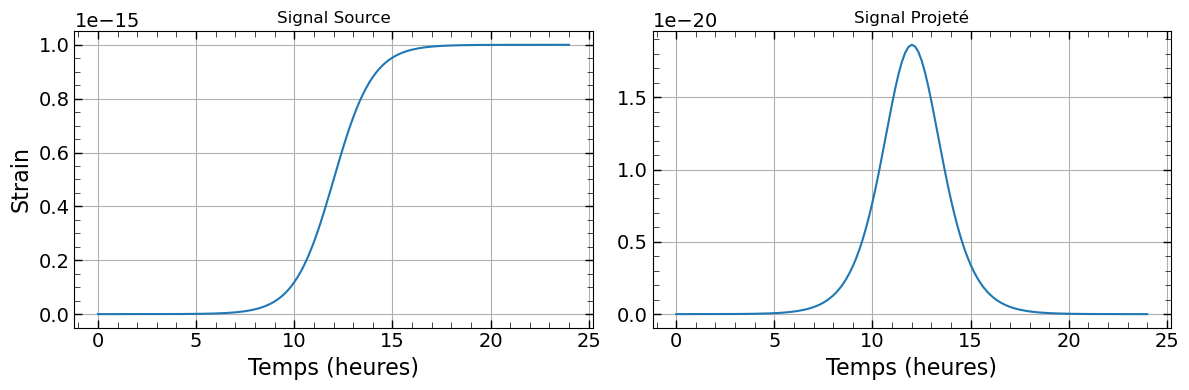

In [ ]:
# ===================================================================
# 1. IMPORTS ET DÉFINITION DE LA CLASSE (Inchangé)
# ===================================================================
import numpy as np
from astropy import units as un
from scipy.interpolate import InterpolatedUnivariateSpline
from ldc.waveform.waveform import HpHc
from ldc.lisa.orbits import Orbits
from ldc.lisa.projection.projectedstrain import ProjectedStrain

class NumericWaveform(HpHc):
    """Classe pour gérer un signal h(t) fourni sous forme de tableaux NumPy."""
    def set_param(self, param, units=None):
        self.p = param
        for key, value in param.items():
            setattr(self, key, value)
        if 'basis' in self.p:
            self.basis = self.p['basis']
        self.check_param()
    def check_param(self):
        needed = ['t', 'hp', 'hc'] # On met à jour ici aussi pour la cohérence
        if not all(k in self.p for k in needed):
            raise ValueError(f"Paramètres manquants. {needed} sont requis.")
        self.hp_interp = InterpolatedUnivariateSpline(self.p['t'], self.p['hp'], ext='zeros')
        self.hc_interp = InterpolatedUnivariateSpline(self.p['t'], self.p['hc'], ext='zeros') # Et ici
    def compute_hphc_td(self, t, **kwargs):
        hp_t = self.hp_interp(t)
        hc_t = self.hc_interp(t) # Et ici
        return hp_t, hc_t

# ===================================================================
# 2. PRÉPARATION DES OBJETS DE BASE (Orbits) (Inchangé)
# ===================================================================
config = {"orbit_type": "analytic", "nominal_arm_length": 2.5e9 * un.m, "initial_rotation": 0 * un.rad, "initial_position": 0 * un.rad}
orbits = Orbits.type(config)

# ===================================================================
# 3. CRÉATION DE VOTRE SIGNAL SIGMOÏDE (Inchangé)
# ===================================================================
t_min = 0; t_max = 86450; dt = 600 
t = np.arange(t_min, t_max, dt)
amplitude_max = 1e-15; t_centre = t_max / 2; largeur = 3600
def sigmoid(t, t0, largeur): return 1 / (1 + np.exp(-(t - t0) / largeur))
hp = amplitude_max * sigmoid(t, t_centre, largeur)
hc = np.zeros_like(t) # On renomme hx en hc
k = np.array([0., 0., 1.]); u = np.array([1., 0., 0.]); v = np.array([0., 1., 0.])

# ===================================================================
# 4. CRÉATION DE L'OBJET SOURCE ET PROJECTION (Modification ici)
# ===================================================================
gw_source = NumericWaveform("sigmoid_memory", "Numeric", "TD")
params = {
    't': t, 
    'hp': hp, 
    'hc': hc,  
    'd_L': 1.0 * un.Gpc,
    'basis': (k, v, u)
}
gw_source.set_param(params)
print("Objet source créé.")

proj = ProjectedStrain(orbits)
yArm = proj.arm_response(t_min, t_max, dt, GWs=[gw_source])
print("Projection terminée ! Shape:", yArm.shape)

# ===================================================================
# 5. VISUALISATION (Inchangé)
# ===================================================================
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1); plt.plot(t / 3600, hp); plt.title("Signal Source"); plt.xlabel("Temps (heures)"); plt.ylabel("Strain"); plt.grid(True)
plt.subplot(1, 2, 2); plt.plot(t / 3600, yArm[:, 0]); plt.title("Signal Projeté"); plt.xlabel("Temps (heures)"); plt.grid(True)
plt.tight_layout(); plt.show()

Les signaux bruts yArm sont dominés par le bruit du laser. Pour annuler ce bruit, on combine les signaux des différents bras de manière astucieuse. C'est le principe du TDI. Les combinaisons les plus courantes sont appelées X, Y, et Z.

Étape 5 terminée : Variables TDI X, Y, Z calculées.


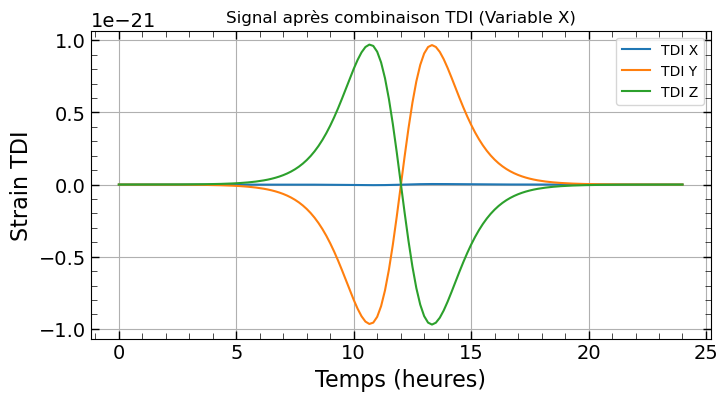

In [15]:
# --- ÉTAPE 5 : Calculer les combinaisons TDI ---

# Calcule la variable TDI X à partir des signaux yArm interpolés
tdi_X = proj.compute_tdi_x(t)

# Calcule la variable TDI Y
tdi_Y = proj.compute_tdi_y(t)

# Calcule la variable TDI Z
tdi_Z = proj.compute_tdi_z(t)

print("Étape 5 terminée : Variables TDI X, Y, Z calculées.")

# Visualisons le TDI X
plt.figure(figsize=(8, 4))
plt.plot(t / 3600, tdi_X, label='TDI X')
plt.plot(t / 3600, tdi_Y, label='TDI Y')
plt.plot(t / 3600, tdi_Z, label='TDI Z')
plt.title("Signal après combinaison TDI (Variable X)")
plt.xlabel("Temps (heures)")
plt.ylabel("Strain TDI")
plt.grid(True)
plt.legend(loc ='best')
plt.show()

In [16]:
# --- ÉTAPE 6 : Calculer la Transformée de Fourier ---

# Calcul de la FFT pour le signal TDI X
# On utilise rfft car notre signal est réel, c'est plus efficace
tilde_X = np.fft.rfft(tdi_X) * dt

# Calcul des fréquences correspondantes
freqs = np.fft.rfftfreq(len(t), d=dt)

print("Étape 6 terminée : Passage en domaine fréquentiel.")

Étape 6 terminée : Passage en domaine fréquentiel.


Étape 7 terminée : PSD du bruit de LISA obtenue.


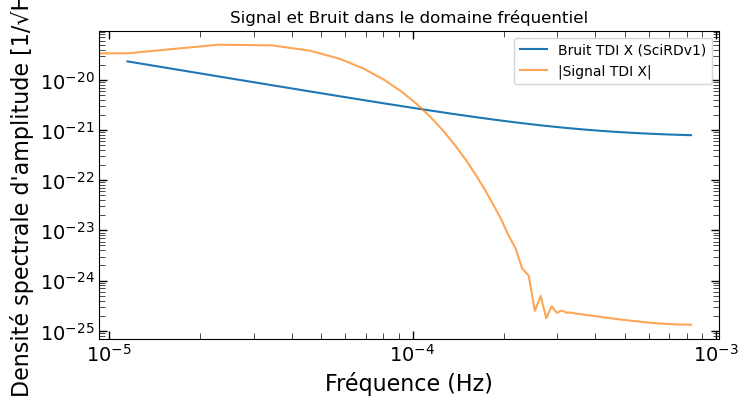

In [17]:
# --- ÉTAPE 7 (Corrigée) : Obtenir le bruit de LISA ---
from ldc.lisa.noise import get_noise_model

# 1. Obtenir l'objet de bruit pour le modèle "SciRDv1"
# On lui passe le tableau de fréquences où l'on veut évaluer le bruit.
noise_model = get_noise_model("SciRDv1", freqs)

# 2. Calculer la PSD du bruit pour les canaux TDI X, Y, Z
# La documentation indique que psd() sans argument retourne le bruit pour le canal X.
# Pour être plus explicite et obtenir les 3, on peut faire :
Sn_X = noise_model.psd(option='X')
Sn_Y = noise_model.psd(option='X') # Pour les bruits analytiques, X, Y, Z sont souvent identiques
Sn_Z = noise_model.psd(option='X')

print("Étape 7 terminée : PSD du bruit de LISA obtenue.")

# Visualisons le bruit (le reste du code est inchangé)
plt.figure(figsize=(8, 4))
plt.loglog(freqs, np.sqrt(Sn_X), label="Bruit TDI X (SciRDv1)")
plt.loglog(freqs, np.abs(tilde_X), label="|Signal TDI X|", alpha=0.7)
plt.xlabel("Fréquence (Hz)")
plt.ylabel("Densité spectrale d'amplitude [1/√Hz]")
plt.title("Signal et Bruit dans le domaine fréquentiel")
plt.legend()


plt.show()

In [18]:
# --- ÉTAPE 8 : Calculer le SNR ---

df = freqs[1] - freqs[0]

# On s'assure de ne pas diviser par zéro si Sn_X[0] est nul
# On commence l'intégration à partir du premier point non nul de fréquence
start_index = 1 if freqs[0] == 0 else 0

# SNR² pour le canal X
snr2_X = 4 * np.sum(np.abs(tilde_X[start_index:])**2 / Sn_X[start_index:]) * df

# SNR² pour le canal Y
tilde_Y = np.fft.rfft(tdi_Y) * dt
snr2_Y = 4 * np.sum(np.abs(tilde_Y[start_index:])**2 / Sn_Y[start_index:]) * df

# SNR² pour le canal Z
tilde_Z = np.fft.rfft(tdi_Z) * dt
snr2_Z = 4 * np.sum(np.abs(tilde_Z[start_index:])**2 / Sn_Z[start_index:]) * df

# Le SNR total est la racine carrée de la somme des SNR²
snr_total = np.sqrt(snr2_X + snr2_Y + snr2_Z)

print("---")
print("Étape 8 terminée : Calcul du SNR.")
print(f"SNR² (X) = {snr2_X:.2f}")
print(f"SNR² (Y) = {snr2_Y:.2f}")
print(f"SNR² (Z) = {snr2_Z:.2f}")
print(f"SNR Total = {snr_total:.2f}")

---
Étape 8 terminée : Calcul du SNR.
SNR² (X) = 0.01
SNR² (Y) = 464.56
SNR² (Z) = 468.27
SNR Total = 30.54


### Plot the response of LISA to the GRB memory signal

In [39]:
# ===================================================================
# UTILISATION DE LA LIBRAIRIE 'lisagwresponse' (Approche finale)
# ===================================================================
import numpy as np
import matplotlib.pyplot as plt
import utils_GRB_afterglow_phenom as ugrb
from lisagwresponse import ReadStrain
from ldc.lisa.orbits import Orbits
from astropy.coordinates import SkyCoord
from astropy import units as u
import h5py
print("--- Utilisation de la librairie lisagwresponse ---")

# --- 1. Paramètres et génération du signal GRB ---
Ej_erg = 1e52
E_aft = 1e52
t_end = 2
distance_pc = 50 * 1e6
theta_ej_rad = np.deg2rad(10)
phi_ej_rad = np.deg2rad(0)

t_max_s = 86400 * 2 # 2 jours
dt = 60 # 1 minute de sampling
t_obs = np.arange(0, t_max_s, dt)

h_in = ugrb.memory_initial_acceleration_GRB(Ej=Ej_erg, theta_ej=theta_ej_rad, phi_ej=phi_ej_rad, d=distance_pc)
h_m = ugrb.memory_afterglow(E_aft, theta_ej_rad, phi_ej_rad, distance_pc)

t_signal, h_signal = ugrb.memory_total_waveform(t_obs=t_obs, h_in=h_in, h_m=h_m,
                                                t_end_injection=t_end, theta_ej=theta_ej_rad,
                                                d=distance_pc, radius=0)
hp_signal = h_signal
hc_signal = np.zeros_like(h_signal)
print("Signal GRB temporel généré.")

# --- 2. Création du fichier d'orbites avec LDC ---
print("--- Génération du fichier d'orbites 'lisa_orbits.h5' ---")

# --- A. Générer les données d'orbite en mémoire avec LDC ---
t_max_s = 86400 * 2 # 2 jours
dt = 60 # 1 minute de sampling
t_orbit = np.arange(0, t_max_s, dt)

print("Calcul des orbites avec LDC...")
config = {"orbit_type": "analytic", "nominal_arm_length": 2.5e9 * u.m, "initial_rotation": 0 * u.rad, "initial_position": 0 * u.rad}
ldc_orbits = Orbits.type(config)


print("Données d'orbite calculées.")

orbit_file = "lisa_orbits.h5"
print(f"Création et écriture du fichier '{orbit_file}'...")

with h5py.File(orbit_file, 'w') as f:
    # Créer des 'datasets' pour chaque tableau de données
    f.create_dataset('t', data=t_orbit)

    
    # Ajouter les attributs/métadonnées que lisagwresponse pourrait attendre
    f.attrs['t0'] = t_orbit[0]
    f.attrs['dt'] = dt
    f.attrs['size'] = len(t_orbit)
    f.attrs['version'] = '1.0'
    f.attrs['description'] = "LISA orbits generated with LDC and saved with h5py"

print(f"Fichier '{orbit_file}' généré avec succès.")

# --- 3. Utilisation de lisagwresponse ---
# Conversion des coordonnées en écliptique (gw_lambda, gw_beta)
ra_source_rad = phi_ej_rad
dec_source_rad = np.pi/2 - theta_ej_rad
coords_icrs = SkyCoord(ra=ra_source_rad*u.rad, dec=dec_source_rad*u.rad, frame='icrs')
coords_ecliptic = coords_icrs.geocentrictrueecliptic
gw_lambda = coords_ecliptic.lon.rad
gw_beta = coords_ecliptic.lat.rad

print("Instanciation de la source avec ReadStrain...")
grb_source = ReadStrain(
    t_signal,
    hp_signal,
    hc_signal,
    orbits=orbit_file,
    gw_lambda=gw_lambda, # Correction: Utiliser les coordonnées écliptiques
    gw_beta=gw_beta      # Correction: Utiliser les coordonnées écliptiques
)

# --- 4. Calcul et affichage de la réponse ---
print("Calcul de la réponse des bras et affichage du graphique...")
fig = grb_source.plot(t_signal)
plt.suptitle("Réponse de LISA au signal GRB (calculée avec lisagwresponse)", y=1.02)
plt.show()

output_filename = "LISA_response_grb_lisagwresponse.png"
print(f"Sauvegarde du graphique dans : {output_filename}")
fig.savefig(output_filename, dpi=150, bbox_inches='tight')

--- Utilisation de la librairie lisagwresponse ---
Signal GRB temporel généré.
--- Génération du fichier d'orbites 'lisa_orbits.h5' ---
Calcul des orbites avec LDC...
Données d'orbite calculées.
Création et écriture du fichier 'lisa_orbits.h5'...
Fichier 'lisa_orbits.h5' généré avec succès.
Instanciation de la source avec ReadStrain...


KeyError: 'Unable to synchronously open object (component not found)'